# Continuous Forward Burgers' Equation

This notebook solves the **forward** 1D Burgers' equation using `pinnstorch`, following the same structure as the Schrödinger tutorial.

### The Problem

$$u_t + u\,u_x - \frac{0.01}{\pi}\,u_{xx} = 0, \quad x \in [-1, 1],\quad t \in [0, 1]$$

With conditions:
- **Initial condition (Given):** $u(0, x) = -\sin(\pi x)$
- **Boundary conditions (Given):** $u(t, -1) = 0$ and $u(t, 1) = 0$
- Finding u(x,t) (fluid velocity)

This is a **forward** problem — we know the PDE parameters and want to find $u(t, x)$ everywhere.

### Architecture
- **Inputs:** $[t, x]$
- **Hidden:** 8 layers × 20 neurons, tanh activation
- **Output:** $[u(t, x)]$

### Data
Uses `burgers_shock.mat` from the [original PINNs repo](https://github.com/maziarraissi/PINNs/tree/master/main/Data). Keys: `x` (256×1), `t` (100×1), `usol` (256×100).

---
## 1. Install & Import Libraries

In [1]:
from typing import Dict

import torch
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import lightning.pytorch as pl

import pinnstorch

/Users/phongdang/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


---
## 2. Define Mesh

Burgers has a simple 1D spatial domain, so we use `pinnstorch.data.Mesh` with separate `TimeDomain` and `Interval` — exactly like Option 1 in the Schrödinger tutorial.

The `read_data_fn` loads the reference solution from `burgers_shock.mat` and returns a dict of solution arrays shaped `(N, T)`.

In [2]:
def read_data_fn(root_path):
    """Load Burgers reference solution from .mat file."""
    data = scipy.io.loadmat(f'{root_path}/burgers_shock.mat')
    # usol is (N, T) — the exact solution on the full grid
    u = np.real(data['usol'])   # (256, 100)
    return {'u': u}

In [3]:
time_domain    = pinnstorch.data.TimeDomain(t_interval=[0, 1], t_points=100)
spatial_domain = pinnstorch.data.Interval(x_interval=[-1, 1], shape=[256, 1])
#25600 mesh points

#Grid of spatial and temporal points
mesh = pinnstorch.data.Mesh(
    root_dir='.',                      # folder containing burgers_shock.mat data
    read_data_fn=read_data_fn,
    spatial_domain=spatial_domain,
    time_domain=time_domain
)

print(f'Domain bounds: lb = {mesh.lb},  ub = {mesh.ub}')

Domain bounds: lb = [-1.  0.],  ub = [1. 1.]


---
## 3. Define Training Datasets

Burgers needs three datasets, mirroring Schrödinger exactly:
1. **Initial condition** — enforces $u(0, x) = -\sin(\pi x)$
2. **Dirichlet boundary condition** — enforces $u(t, \pm 1) = 0$
3. **Collocation points** — enforces the PDE residual $f = 0$ inside the domain

In [4]:
# ── Initial condition: u(0, x) = -sin(πx) ───────────────────────────────────
def initial_fn(x):
    return {'u': -np.sin(np.pi * x)}

ic = pinnstorch.data.InitialCondition(
    mesh=mesh,
    num_sample=50,
    initial_fun=initial_fn,
    solution=['u']
)

In [5]:
# ── Boundary condition: u(t, -1) = 0,  u(t, 1) = 0 ────────────────
bc = pinnstorch.data.DirichletBoundaryCondition(
    mesh=mesh,
    num_sample=50,
    solution=['u']
)

In [6]:
# ── Collocation points: PDE residual f = 0 ───────────────────────────────────
#10,000 random points scattered inside the domain
col = pinnstorch.data.MeshSampler(
    mesh=mesh,
    num_sample=10000,
    collection_points=['f_u']
)

train_datasets = [ic, bc, col]
print('Training datasets defined.')

Training datasets defined.


---
## 4. Define Validation Dataset

Validate on a sample of mesh points against the reference solution `u`.

> **Note:** Always set `num_sample` — leaving it unset passes the entire mesh at once and will crash the network.

In [7]:
val_dataset = pinnstorch.data.MeshSampler(
    mesh=mesh,
    num_sample=500,
    solution=['u']
)

---
## 5. Define the Neural Network

- First element of `layers` = number of **spatial dimensions** (1 for Burgers — just `x`)
- `pinnstorch` appends time internally, so the real first layer is 2 neurons wide

- 2 Input Layers: x, t
- 8 Hidden layers, 20 neurons each: 
-   Too few layers = low capacity for training complex data
-   Too many: overtrains and expensive
- 1 Output Layer: u(x,t)

In [8]:
net = pinnstorch.models.FCN( #Fully Connected Network
    layers=[2, 20, 20, 20, 20, 20, 20, 20, 20, 1],  
    output_names=['u'],
    lb=mesh.lb,
    ub=mesh.ub
)

---
## 6. Define `pde_fn`

The Burgers PDE residual:
$$f = u_t + u\,u_x - \frac{0.01}{\pi}\,u_{xx}$$

**Important:** argument order is always `(outputs, *spatial, time)` — spatial dimensions first, time last. For Burgers that means `(outputs, x, t)`.

In [9]:
def pde_fn(
    outputs: Dict[str, torch.Tensor],
    x: torch.Tensor,
    t: torch.Tensor
):
    """Burgers PDE residual. Spatial (x) first, time (t) last."""
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = outputs['u']

    u_x, u_t = pinnstorch.utils.gradient(u, [x, t])
    u_xx      = pinnstorch.utils.gradient(u_x, [x])[0]

    outputs['f_u'] = u_t + u * u_x - (0.01 / np.pi) * u_xx

    return outputs

---
## 7. Define `PINNDataModule` and `PINNModule`

This is a **forward** problem so there are no `extra_variables`. Loss function is MSE as specified in the paper.

In [10]:
#Organize sets
datamodule = pinnstorch.data.PINNDataModule(
    train_datasets=train_datasets,
    val_dataset=val_dataset,
    pred_dataset=val_dataset
)

In [11]:
#Connects everything
model = pinnstorch.models.PINNModule(
    net=net,
    pde_fn=pde_fn,
    loss_fn='mse'
)

---
## 8. Train

In [19]:
#2000 Passes through data, at end satisfies ic, bc, and PDE
trainer = pl.Trainer(
    accelerator='cpu',
    devices=1,
    max_epochs=2000,
    enable_progress_bar=True,
    log_every_n_steps=50
)

trainer.fit(model=model, datamodule=datamodule)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type       ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ net           │ FCN        │  3.0 K │ eval │     0 │
│ 1 │ train_loss    │ MeanMetric │      0 │ eval │     0 │
│ 2 │ val_loss      │ MeanMetric │      0 │ eval │     0 │
│ 3 │ val_error     │ MeanMetric │      0 │ eval │     0 │
│ 4 │ test_loss     │ MeanMetric │      0 │ eval │     0 │
│ 5 │ test_error    │ MeanMetric │      0 │ eval │     0 │
│ 6 │ val_loss_best │ MinMetric  │      0 │ eval │     0 │
└───┴───────────────┴────────────┴────────┴──────┴───────┘

Trainable params: 3.0 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.0 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 0                                                                                           
Modules in eval mode: 25                                                                                           
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


/home/jakegils/.local/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training 
batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

/home/jakegils/.local/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 26 module(s) in 
eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, 
you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=2000` reached.


---
## 9. Validate
- 5% error not desirable, increased accuracy can be achieved by increasing the number of epochs
- Target <1%

In [20]:
trainer.validate(model=model, datamodule=datamodule)

SLURM auto-requeueing enabled. Setting signal handlers.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        val/error_u        │    0.05003475770354271    │
│         val/loss          │   0.0009777987143024802   │
│       val/loss_best       │   0.0009777987143024802   │
└───────────────────────────┴───────────────────────────┘

[{'val/loss': 0.0009777987143024802,
  'val/error_u': 0.05003475770354271,
  'val/loss_best': 0.0009777987143024802}]

---
## 10. Predict & Plot

Three plots following the Schrödinger tutorial style:
1. **Full solution heatmap** — predicted $u(t, x)$ over the entire domain
2. **Snapshots** — exact vs predicted at three time slices
3. **Scatter** — predicted vs exact for all validation points

In [21]:
# ── Get predictions ──────────────────────────────────────────────────────────
preds_list = trainer.predict(model=model, datamodule=datamodule)
preds      = pinnstorch.utils.fix_predictions(preds_list)
u_pred     = preds['u'].cpu().numpy().flatten()

print(f'Predictions shape: {u_pred.shape}')

SLURM auto-requeueing enabled. Setting signal handlers.


Predictions shape: (500,)


In [22]:
# ── Load full reference solution for plotting ────────────────────────────────
data   = scipy.io.loadmat('burgers_shock.mat')
x_grid = data['x'].flatten()      # (256,)
t_grid = data['t'].flatten()      # (100,)
U_ref  = np.real(data['usol'])    # (256, 100)

TT, XX = np.meshgrid(t_grid, x_grid)   # both (256, 100)

# Predict on the full grid
x_flat = torch.tensor(XX.flatten()[:, None], dtype=torch.float32)
t_flat = torch.tensor(TT.flatten()[:, None], dtype=torch.float32)

model.eval()
with torch.no_grad():
    out    = model.net([x_flat], t_flat)
U_pred = out['u'].numpy().reshape(256, 100)

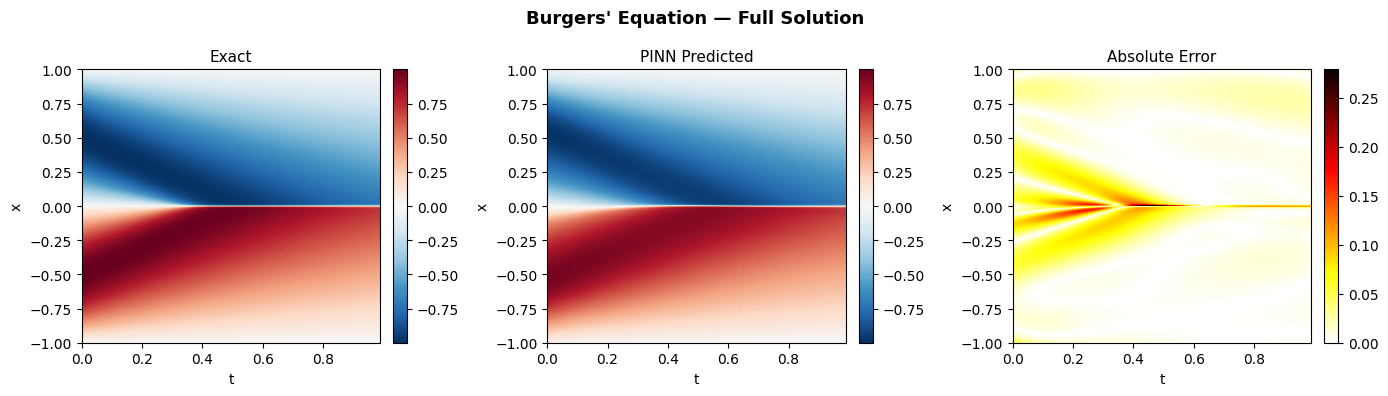

Saved → burgers_heatmap.png


In [23]:
# ── Plot 1: Solution heatmaps side by side ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Burgers' Equation — Full Solution", fontsize=13, fontweight='bold')

vmin, vmax = U_ref.min(), U_ref.max()
kw = dict(aspect='auto', origin='lower', cmap='RdBu_r',
          vmin=vmin, vmax=vmax,
          extent=[t_grid.min(), t_grid.max(), x_grid.min(), x_grid.max()])

im0 = axes[0].imshow(U_ref,  **kw)
im1 = axes[1].imshow(U_pred, **kw)
im2 = axes[2].imshow(np.abs(U_pred - U_ref), aspect='auto', origin='lower',
                     cmap='hot_r', vmin=0,
                     extent=[t_grid.min(), t_grid.max(), x_grid.min(), x_grid.max()])

for ax, title, im in zip(axes,
                         ['Exact', 'PINN Predicted', 'Absolute Error'],
                         [im0, im1, im2]):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('t'); ax.set_ylabel('x')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('burgers_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → burgers_heatmap.png')

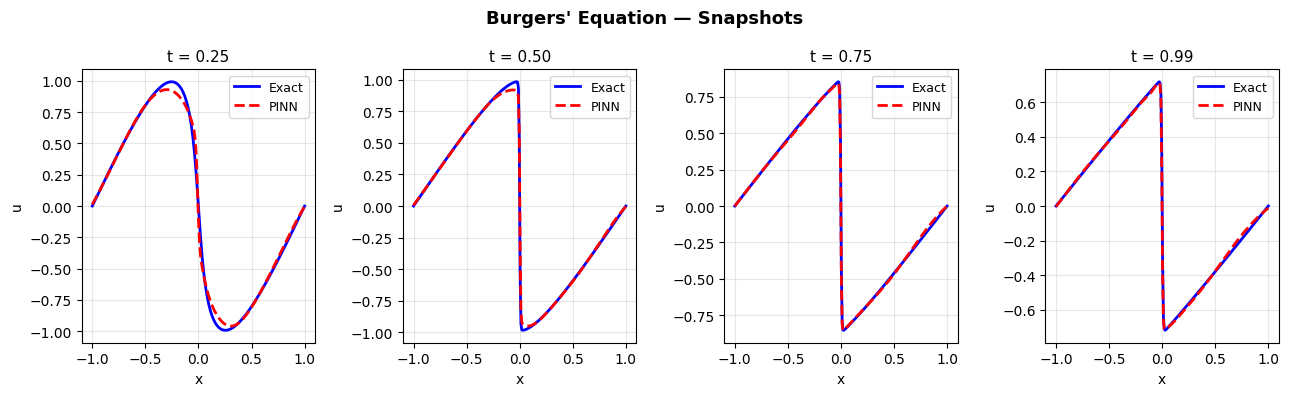

Saved → burgers_snapshots.png


In [29]:
# ── Plot 2: Snapshots at t = 0.25, 0.50, 0.75 ───────────────────────────────
snap_times = [0.25, 0.50, 0.75, .99]

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
fig.suptitle("Burgers' Equation — Snapshots", fontsize=13, fontweight='bold')

for ax, t_val in zip(axes, snap_times):
    t_idx = np.argmin(np.abs(t_grid - t_val))
    ax.plot(x_grid, U_ref[:, t_idx],  'b-',  linewidth=2,   label='Exact')
    ax.plot(x_grid, U_pred[:, t_idx], 'r--', linewidth=2,   label='PINN')
    ax.set_title(f't = {t_val:.2f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('burgers_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → burgers_snapshots.png')

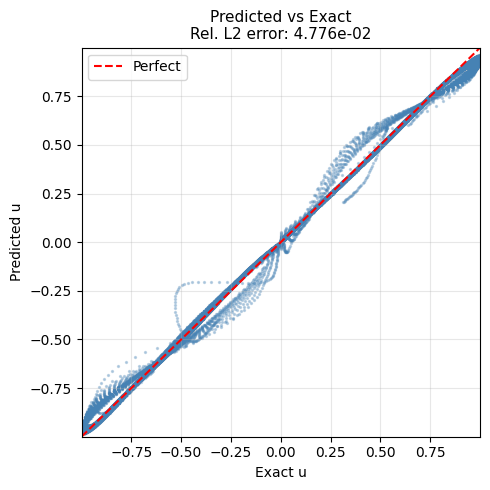

Saved → burgers_scatter.png

Relative L2 error: 4.7758e-02


In [25]:
# ── Plot 3: Predicted vs Exact scatter ───────────────────────────────────────
u_ref_flat  = U_ref.flatten()
u_pred_flat = U_pred.flatten()
rel_l2 = np.linalg.norm(u_pred_flat - u_ref_flat) / np.linalg.norm(u_ref_flat)

fig, ax = plt.subplots(figsize=(5, 5))
lim = [u_ref_flat.min(), u_ref_flat.max()]
ax.scatter(u_ref_flat, u_pred_flat, s=2, alpha=0.3, color='steelblue')
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Exact u'); ax.set_ylabel('Predicted u')
ax.set_title(f"Predicted vs Exact\nRel. L2 error: {rel_l2:.3e}", fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('burgers_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → burgers_scatter.png')
print(f'\nRelative L2 error: {rel_l2:.4e}')

---
## Summary

| Step | What we did |
|------|-------------|
| Mesh | `Mesh` with `TimeDomain` + `Interval` over $t∈[0,1]$, $x∈[-1,1]$ |
| IC | 50 samples of $u(0,x) = -\sin(\pi x)$ via `InitialCondition` |
| BC | 50 samples of $u(t,\pm1) = 0$ via `DirichletBoundaryCondition` |
| Collocation | 10000 interior points via `MeshSampler` |
| Network | `FCN` — 1 spatial dim → 8×20 hidden → 1 output $u$ |
| `pde_fn` | $f = u_t + u\,u_x - (0.01/\pi)\,u_{xx}$ |
| Training | MSE loss, 200 epochs |

**Key rules learned from debugging:**
- `layers[0]` in `FCN` = number of spatial dimensions, not total inputs
- `output_fn` / `pde_fn` argument order is always `(outputs, *spatial, time)` — spatial first, time last
- Always call `x.requires_grad_(True)` and `t.requires_grad_(True)` inside `pde_fn`
- Always set `num_sample` on the validation `MeshSampler`